In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df=pd.read_csv("/content/Air_Quality-selected-columns.csv")

In [47]:
df.head()

,id,state,city,station,pollutant_id,last_update,pollutant_min,pollutant_max,pollutant_avg
0,1,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,21-10-2021,69.0,109.0,86.0
1,2,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,21-10-2021,82.0,138.0,105.0
2,3,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,21-10-2021,10.0,42.0,19.0
3,4,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,21-10-2021,4.0,5.0,4.0
4,5,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,21-10-2021,16.0,42.0,27.0


In [24]:
df.describe()

,id,pollutant_min,pollutant_max,pollutant_avg
count,1836.000000,1738.000000,1738.000000,1738.000000
mean,918.500000,28.414269,96.873418,54.100690
std,530.151865,34.403811,104.765094,60.824158
min,1.000000,1.000000,1.000000,1.000000
25%,459.750000,5.000000,21.000000,12.000000
50%,918.500000,14.000000,63.000000,31.000000
75%,1377.250000,39.000000,124.000000,70.000000
max,1836.000000,217.000000,500.000000,314.000000


In [25]:
print("shape:",df.shape)

shape: (1836, 9)


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1836 non-null   int64  
 1   state          1836 non-null   object 
 2   city           1836 non-null   object 
 3   station        1836 non-null   object 
 4   pollutant_id   1836 non-null   object 
 5   last_update    1836 non-null   object 
 6   pollutant_min  1738 non-null   float64
 7   pollutant_max  1738 non-null   float64
 8   pollutant_avg  1738 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 129.2+ KB


In [27]:
print(df.isnull().sum())

id                0
state             0
city              0
station           0
pollutant_id      0
last_update       0
pollutant_min    98
pollutant_max    98
pollutant_avg    98
dtype: int64


In [28]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [33]:
print(df[['pollutant_min','pollutant_max','pollutant_avg']].mean())

pollutant_min    28.414269
pollutant_max    96.873418
pollutant_avg    54.100690
dtype: float64


In [34]:
print(df[['pollutant_min','pollutant_max','pollutant_avg']].median())

pollutant_min    14.0
pollutant_max    63.0
pollutant_avg    31.0
dtype: float64


In [35]:
print(df[['pollutant_min','pollutant_max','pollutant_avg']].mode())

   pollutant_min  pollutant_max  pollutant_avg
0            1.0            6.0            5.0


In [36]:
print(df[['pollutant_min','pollutant_max', 'pollutant_avg']].std())

pollutant_min     34.403811
pollutant_max    104.765094
pollutant_avg     60.824158
dtype: float64


In [38]:
print(df[['pollutant_min','pollutant_max','pollutant_avg']].min())


pollutant_min    1.0
pollutant_max    1.0
pollutant_avg    1.0
dtype: float64


In [39]:
print(df[['pollutant_min','pollutant_max','pollutant_avg']].max())

pollutant_min    217.0
pollutant_max    500.0
pollutant_avg    314.0
dtype: float64


In [40]:
print("Unique States :", df["state"].nunique())

Unique States : 26


In [41]:
print(df["pollutant_id"].value_counts())

pollutant_id
CO       273
PM2.5    272
NO2      271
PM10     267
SO2      260
OZONE    258
NH3      235
Name: count, dtype: int64


In [42]:
city_avg = df.groupby("city")["pollutant_avg"].mean()

print(city_avg.sort_values(ascending=False))

city
Muzaffarnagar    104.857143
Ghaziabad        102.629630
Meerut           100.450000
Bulandshahr       97.142857
Ballabgarh        96.857143
                    ...    
Guwahati          17.923077
Durgapur          17.333333
Kohima            15.857143
Aizawl            12.666667
Shillong          10.750000
Name: pollutant_avg, Length: 142, dtype: float64


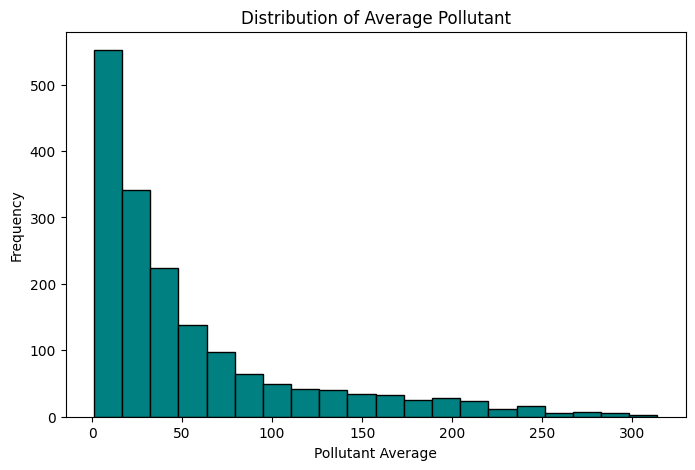

In [44]:
plt.figure(figsize=(8,5))
plt.hist(df["pollutant_avg"], bins=20, edgecolor="black",color='teal')

plt.title("Distribution of Average Pollutant")
plt.xlabel("Pollutant Average")
plt.ylabel("Frequency")

plt.show()

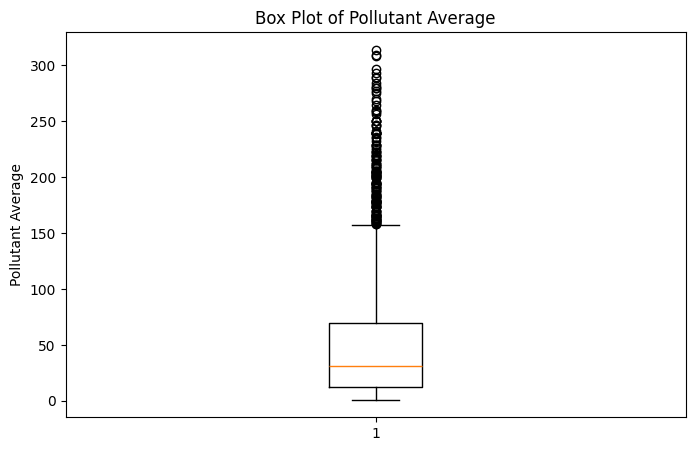

In [45]:
plt.figure(figsize=(8,5))

plt.boxplot(df["pollutant_avg"].dropna())

plt.title("Box Plot of Pollutant Average")
plt.ylabel("Pollutant Average")

plt.show()

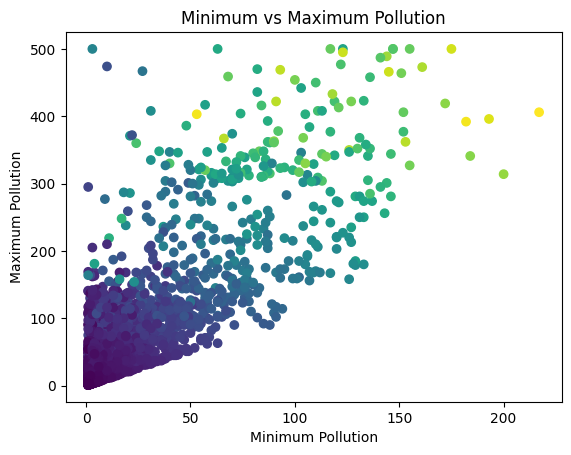

In [49]:
plt.scatter(df["pollutant_min"],df["pollutant_max"],c=df['pollutant_avg'])
plt.xlabel("Minimum Pollution")
plt.ylabel("Maximum Pollution")
plt.title("Minimum vs Maximum Pollution")
plt.show()

In [51]:
state = df.groupby("state")["pollutant_avg"].mean()

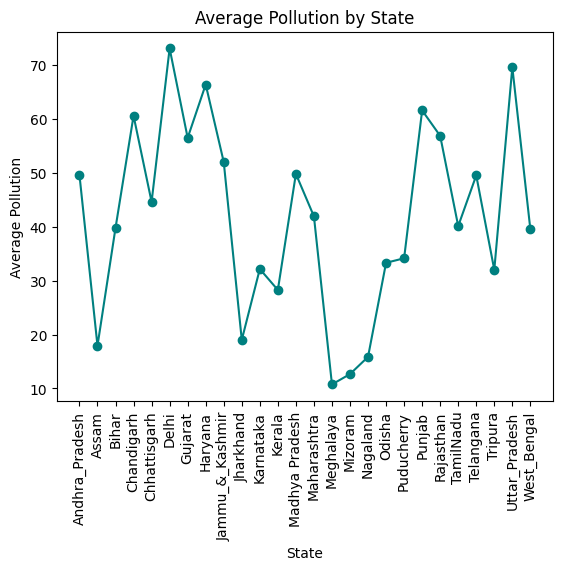

In [53]:
plt.plot(state.index, state.values,marker="o",color='teal')
plt.xticks(rotation=90)
plt.title("Average Pollution by State")
plt.xlabel("State")
plt.ylabel("Average Pollution")
plt.show()

In [54]:
counts = df["pollutant_id"].value_counts()

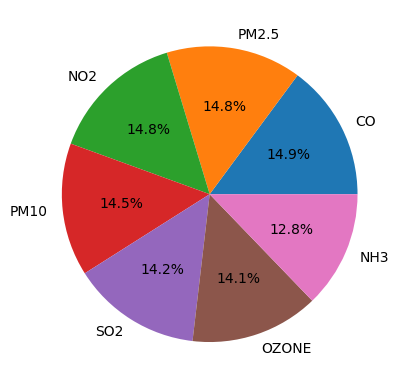

In [56]:
plt.pie(counts,labels=counts.index,autopct="%1.1f%%")

plt.show()